In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import joblib

In [17]:
df = pd.read_csv('database/train_mod_tratado.csv')

In [18]:
# Removemos o topo 5% e a base 1% para evitar ruídos de preços irreais ou carros de luxo extremos
q_low = df["Preco"].quantile(0.01)
q_hi  = df["Preco"].quantile(0.95)
df_filtered = df[(df["Preco"] < q_hi) & (df["Preco"] > q_low)].copy()

In [19]:
target = 'Preco'
categorical_features = ['Fabricante', 'Modelo', 'Categoria', 'Combustivel', 'Tipo_cambio', 'Tração']
numeric_features = ['Ano', 'Volume_motor', 'Km', 'Airbags', 'Idade']

In [20]:
X = df_filtered[categorical_features + numeric_features]
y = df_filtered[target]

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
base_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor)
])

In [24]:
param_grid_ridge = {
    "regressor__alpha": [0.1, 1.0, 10.0]
}
model_ridge = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge())
])
grid_ridge = GridSearchCV(model_ridge, param_grid_ridge, cv=3, scoring="r2", n_jobs=-1)
grid_ridge.fit(X_train, y_train)
best_ridge = grid_ridge.best_estimator_

In [25]:
param_grid_rf = {
    "regressor__n_estimators": [50, 100],
    "regressor__max_depth": [10, 15]
}
model_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])
grid_rf = GridSearchCV(model_rf, param_grid_rf, cv=3, scoring="r2", n_jobs=-1)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

In [26]:
param_grid_gb = {
    "regressor__n_estimators": [50, 100],
    "regressor__learning_rate": [0.05, 0.1],
    "regressor__max_depth": [3, 5]
}
model_gb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(random_state=42))
])
grid_gb = GridSearchCV(model_gb, param_grid_gb, cv=3, scoring="r2", n_jobs=-1)
grid_gb.fit(X_train, y_train)
best_gb = grid_gb.best_estimator_


In [27]:
models = {
    "Ridge Regression": best_ridge,
    "Random Forest": best_rf,
    "Gradient Boosting": best_gb
}

results = []
best_r2 = -np.inf
best_model_name = ""
best_model_instance = None

In [28]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({"Modelo": name, "RMSE": rmse, "MAE": mae, "R2": r2})

    if r2 > best_r2:
        best_r2 = r2
        best_model_name = name
        best_model_instance = model

results_df = pd.DataFrame(results)
print("\n--- Resultados da Avaliação ---")
print(results_df)


--- Resultados da Avaliação ---
              Modelo         RMSE          MAE        R2
0   Ridge Regression  9482.645456  7281.871152  0.397762
1      Random Forest  6695.726221  4470.383519  0.699735
2  Gradient Boosting  7438.608255  5363.487421  0.629411



Gráfico 'comparacao_modelos_grid_search.png' gerado com sucesso.


C:\Users\pertile\AppData\Local\Temp\1\ipykernel_24444\1858733678.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Modelo", y="R2", data=results_df, palette="viridis")


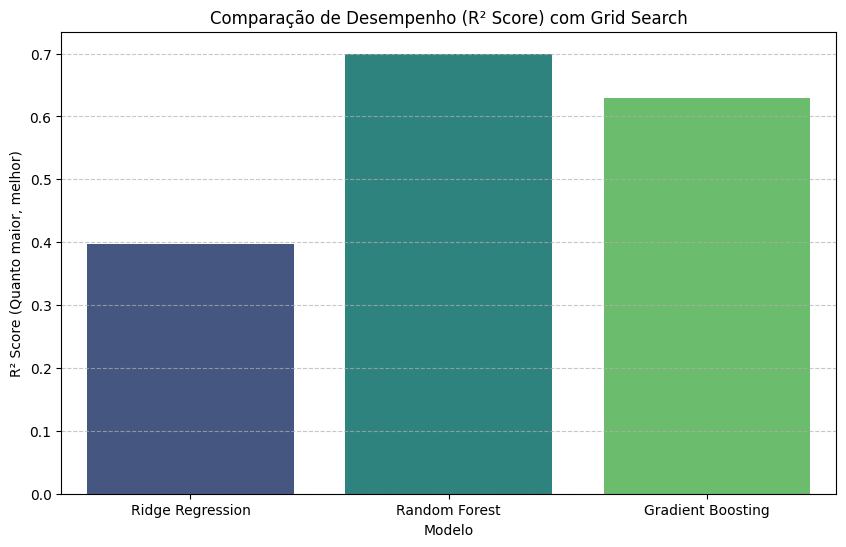

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Modelo", y="R2", data=results_df, palette="viridis")
plt.title("Comparação de Desempenho (R² Score) com Grid Search")
plt.ylabel("R² Score (Quanto maior, melhor)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig("comparacao_modelos_grid_search.png")
print("\nGráfico 'comparacao_modelos_grid_search.png' gerado com sucesso.")

In [ ]:
if best_model_instance:
    model_filename = "models/best_regression_model.pkl"
    joblib.dump(best_model_instance, model_filename)
    print(f"\nO melhor modelo ({best_model_name}) foi salvo como '{model_filename}'.")


O melhor modelo (Random Forest) foi salvo como 'best_regression_model.pkl'.


In [31]:
exemplo = X_test.iloc[[0]]
pred = best_model_instance.predict(exemplo)
print(f"Valor Real: {y_test.iloc[0]:.2f} | Valor Predito: {pred[0]:.2f}")

Valor Real: 16308.00 | Valor Predito: 17627.91
